In [40]:
from matplotlib import pyplot as plt
import numpy as np
import json
import cv2
import os

# import a lot of things from keras:
# sequential model
from keras.models import load_model

# convert data to categorial vector representation
from keras.utils import to_categorical

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# nice progress bar for loading data
from tqdm.notebook import tqdm

# include only those gestures
CONDITIONS = ['like', 'rock', 'peace']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

PATH = './dataset'

## helper function to load and parse annotations

In [41]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

## helper function to pre-process images (color channel conversion and resizing)

In [42]:
def preprocess_image(img):
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [43]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [44]:
# Convert to float
images = np.array(images).astype('float32')
# Normalization [0,1]
images = images / 255.

# Convert interger class labels in to one hot vector
labels_one_hot = to_categorical(labels)

# rename for demonstration purposes
test_label = labels_one_hot

images = images.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

## loading the model

In [45]:
model = load_model('gesture_recognition.keras')

## visualize classification results with a confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
before [[9.9999988e-01 7.0584207e-08 1.0191593e-15 5.4915059e-09]
 [4.5252433e-13 1.0000000e+00 2.9553193e-15 1.8756655e-15]
 [6.3486308e-01 3.5640457e-01 7.9797246e-03 7.5265806e-04]
 [6.4320875e-12 1.0000000e+00 5.6274768e-15 1.5227437e-14]
 [4.0658779e-02 1.1994565e-01 2.3983637e-06 8.3939314e-01]
 [4.9067141e-05 7.7231159e-03 9.6896005e-01 2.3267768e-02]
 [1.3192602e-11 1.0000000e+00 7.7049952e-14 4.9093607e-13]
 [3.0979762e-04 3.8718110e-01 5.8947837e-01 2.3030682e-02]
 [1.7555010e-09 3.6873907e-02 9.6039957e-01 2.7265362e-03]
 [6.9727044e-05 4.2873417e-06 2.6451849e-05 9.9989951e-01]
 [2.5025300e-13 1.0000000e+00 2.3213457e-13 3.8674931e-14]
 [2.9135278e-01 7.5297649e-03 5.2958964e-03 6.9582152e-01]
 [1.0162008e-12 1.0000000e+00 9.4523346e-15 8.5302249e-15]
 [3.9459732e-03 2.6162399e-05 1.4645284e-05 9.9601328e-01]]
probabilities [0 1 0 1 3 2 1 2 2 3 1 3 1 3]


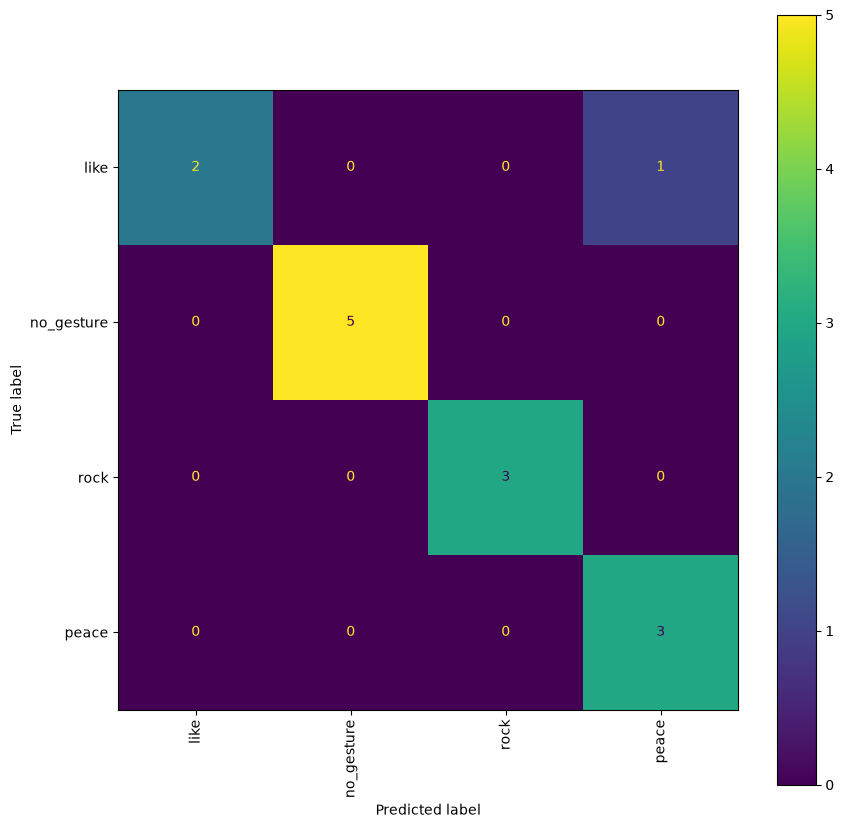

In [46]:
# let the model make predictions for our test data
y_predictions = model.predict(images)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(labels, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass